# Dataset 2 — Vendas no Varejo PE (≤500 pontos)

## Projeto de Deep Learning para Dados Tabulares e Séries Temporais

**Dataset:** Índice mensal de vendas no varejo em Pernambuco. **189 observações.**

| Divisão   | % |
|-----------|---|
| Treino    | 50% |
| Validação | 25% |
| Teste     | 25% |

**Cenário:** Previsão one-step-ahead
**Métricas:** MSE (Mean Squared Error) e MAPE (Mean Absolute Percentage Error)


## 1. Bibliotecas e Funções Auxiliares

In [ ]:
import os, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Bibliotecas carregadas!")

Bibliotecas carregadas!


In [ ]:
DATASETS_DIR = os.path.join(os.getcwd(), 'datasets')

def testar_estacionariedade(serie, nome="Série", sig=0.05):
    result = adfuller(serie.dropna())
    p = result[1]
    print(f"  ADF [{nome}] — estatística: {result[0]:.4f} | p-valor: {p:.4f} | {'Estacionária ✓' if p <= sig else 'NÃO estacionária ✗'}")
    return p <= sig

def determinar_d(serie, sig=0.05):
    s = serie.copy().dropna()
    d = 0
    print("Determinando parâmetro d:")
    while not testar_estacionariedade(s, f"d={d}", sig):
        s = s.diff().dropna()
        d += 1
        if d > 3:
            break
    print(f"  → d = {d}")
    return d

def criar_janelas(arr, janela):
    X, y = [], []
    for i in range(len(arr) - janela):
        X.append(arr[i:i+janela])
        y.append(arr[i+janela])
    return np.array(X), np.array(y)

def metricas(y_true, y_pred, label=""):
    mse  = mean_squared_error(np.array(y_true).flatten(), np.array(y_pred).flatten())
    mape = mean_absolute_percentage_error(np.array(y_true).flatten(), np.array(y_pred).flatten())
    if label:
        print(f"  {label}:  MSE={mse:.6f}  MAPE={mape:.4%}")
    return mse, mape

print("Funções auxiliares definidas!")

Funções auxiliares definidas!


## 2. Carregamento e Análise Exploratória

In [ ]:
df = pd.read_excel(os.path.join(DATASETS_DIR, 'vendas_varejo.xlsx'))
df = df.rename(columns={'Data': 'time', 'Indice': 'valor'})
df['time'] = pd.to_datetime(df['time'])
df = df.set_index('time')
serie = df['valor'].astype(float)

print(f"Tamanho: {len(serie)} obs | {serie.index[0]} → {serie.index[-1]}")
print(serie.describe())

Tamanho: 189 obs | 2000-01-01 00:00:00 → 2015-09-01 00:00:00
count    189.000000
mean      80.380423
std       23.647788
min       49.500000
25%       57.800000
50%       76.300000
75%      101.600000
max      150.600000
Name: valor, dtype: float64


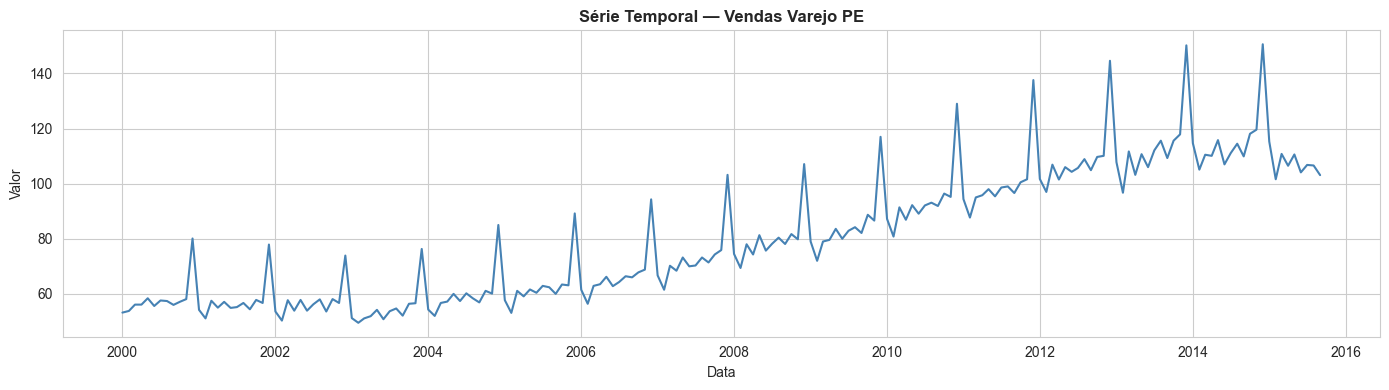

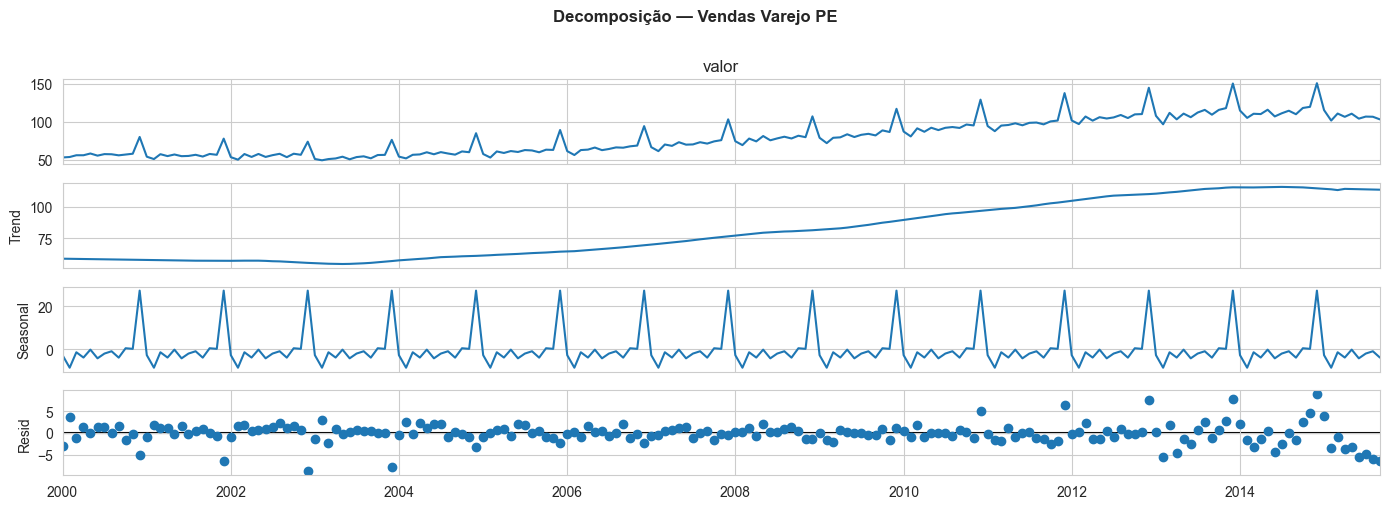

In [ ]:
# Visualização da série completa
plt.figure(figsize=(14, 4))
plt.plot(serie, color='steelblue')
plt.title('Série Temporal — Vendas Varejo PE', fontweight='bold')
plt.xlabel('Data'); plt.ylabel('Valor')
plt.tight_layout(); plt.show()

# Decomposição
decomp = seasonal_decompose(serie.dropna(), model='additive', period=12, extrapolate_trend='freq')
fig = decomp.plot()
fig.suptitle('Decomposição — Vendas Varejo PE', y=1.01, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Divisão Treino / Validação / Teste (50% / 25% / 25%)

Total: 189 | Treino: 94 | Validação: 47 | Teste: 48


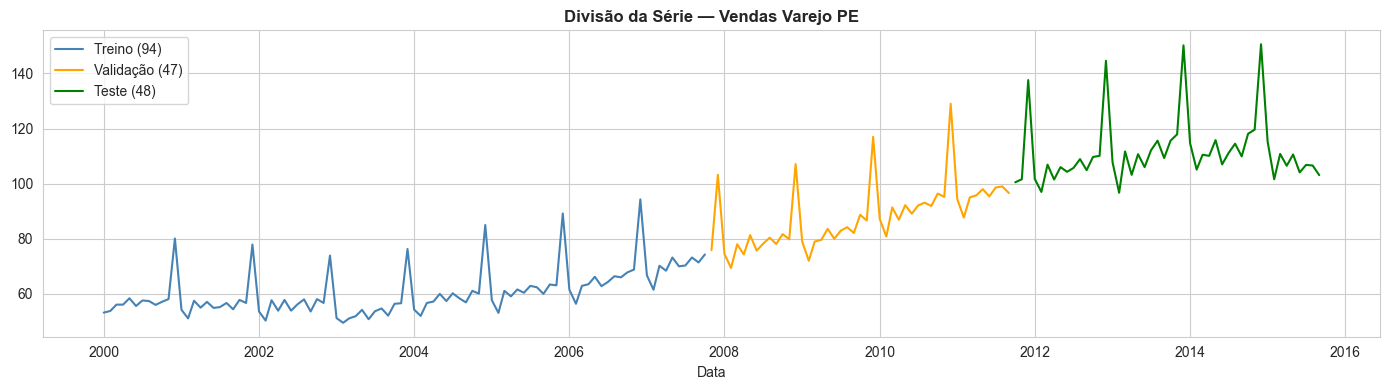

In [ ]:
n = len(serie)
train_size = int(n * 0.50)
val_size   = int(n * 0.25)

train = serie.iloc[:train_size]
val   = serie.iloc[train_size:train_size + val_size]
test  = serie.iloc[train_size + val_size:]

print(f"Total: {n} | Treino: {len(train)} | Validação: {len(val)} | Teste: {len(test)}")

plt.figure(figsize=(14, 4))
plt.plot(train, label=f'Treino ({len(train)})',     color='steelblue')
plt.plot(val,   label=f'Validação ({len(val)})',    color='orange')
plt.plot(test,  label=f'Teste ({len(test)})',       color='green')
plt.title('Divisão da Série — Vendas Varejo PE', fontweight='bold')
plt.xlabel('Data'); plt.legend(); plt.tight_layout(); plt.show()

## 4. Normalização (MinMaxScaler [0.1, 0.9])

In [ ]:
scaler = MinMaxScaler(feature_range=(0.1, 0.9))
train_sc = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
val_sc   = scaler.transform(val.values.reshape(-1, 1)).flatten()
test_sc  = scaler.transform(test.values.reshape(-1, 1)).flatten()

train_s = pd.Series(train_sc, index=train.index)
val_s   = pd.Series(val_sc,   index=val.index)
test_s  = pd.Series(test_sc,  index=test.index)

print(f"Treino normalizado — min: {train_sc.min():.3f} | max: {train_sc.max():.3f}")

Treino normalizado — min: 0.100 | max: 0.900


---
## 5. Modelo 1 — ARIMA (Metodologia Box & Jenkins)

### 5.1 Teste de Estacionariedade — Parâmetro d

In [ ]:
d = determinar_d(train_s)

Determinando parâmetro d:
  ADF [d=0] — estatística: 1.8137 | p-valor: 0.9984 | NÃO estacionária ✗
  ADF [d=1] — estatística: -1.3949 | p-valor: 0.5847 | NÃO estacionária ✗
  ADF [d=2] — estatística: -9.9397 | p-valor: 0.0000 | Estacionária ✓
  → d = 2


### 5.2 Análise ACF e PACF — Parâmetros p e q

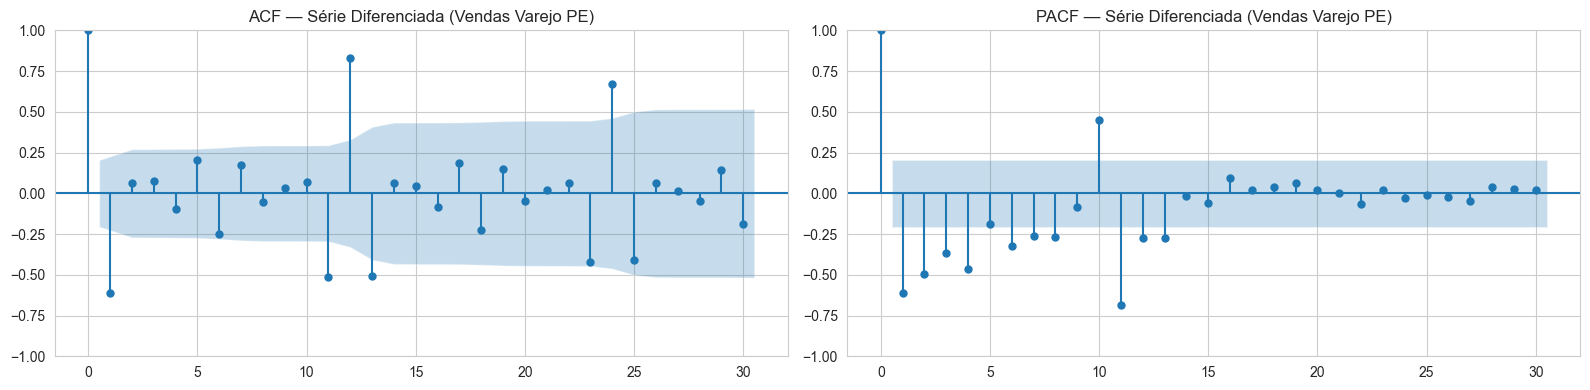

In [ ]:
serie_diff = train_s.copy()
for _ in range(d):
    serie_diff = serie_diff.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf( serie_diff, lags=min(30, len(serie_diff)//3), ax=axes[0])
axes[0].set_title('ACF — Série Diferenciada (Vendas Varejo PE)')
plot_pacf(serie_diff, lags=min(30, len(serie_diff)//3), ax=axes[1])
axes[1].set_title('PACF — Série Diferenciada (Vendas Varejo PE)')
plt.tight_layout(); plt.show()

### 5.3 Grid Search — Seleção por AIC

In [ ]:
resultados = []
for p, q in itertools.product(range(4), range(4)):
    try:
        m = ARIMA(train_s, order=(p, d, q)).fit()
        resultados.append({'p': p, 'd': d, 'q': q, 'AIC': round(m.aic, 2), 'BIC': round(m.bic, 2)})
    except Exception:
        pass

df_aic = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
print("Top 5 modelos ARIMA por AIC:")
print(df_aic.head(5).to_string(index=False))

best_order = tuple(df_aic.iloc[0][['p', 'd', 'q']].astype(int).values)
print(f"\nMelhor ordem selecionada: ARIMA{best_order}")

Top 5 modelos ARIMA por AIC:
 p  d  q     AIC    BIC
 0  2  2 -101.07 -93.51
 0  2  3  -99.15 -89.06
 2  2  2  -98.50 -85.89
 1  2  2  -97.98 -87.89
 1  2  3  -97.70 -85.09

Melhor ordem selecionada: ARIMA(np.int64(0), np.int64(2), np.int64(2))


### 5.4 Ajuste do Melhor Modelo e Análise dos Resíduos

In [ ]:
arima_fit = ARIMA(train_s, order=best_order).fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   94
Model:                 ARIMA(0, 2, 2)   Log Likelihood                  53.536
Date:                Sat, 07 Mar 2026   AIC                           -101.071
Time:                        11:08:25   BIC                            -93.506
Sample:                    01-01-2000   HQIC                           -98.018
                         - 10-01-2007                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.9322      0.056    -34.438      0.000      -2.042      -1.822
ma.L2          0.9413      0.056     16.902      0.000       0.832       1.050
sigma2         0.0166      0.001     11.574      0.0

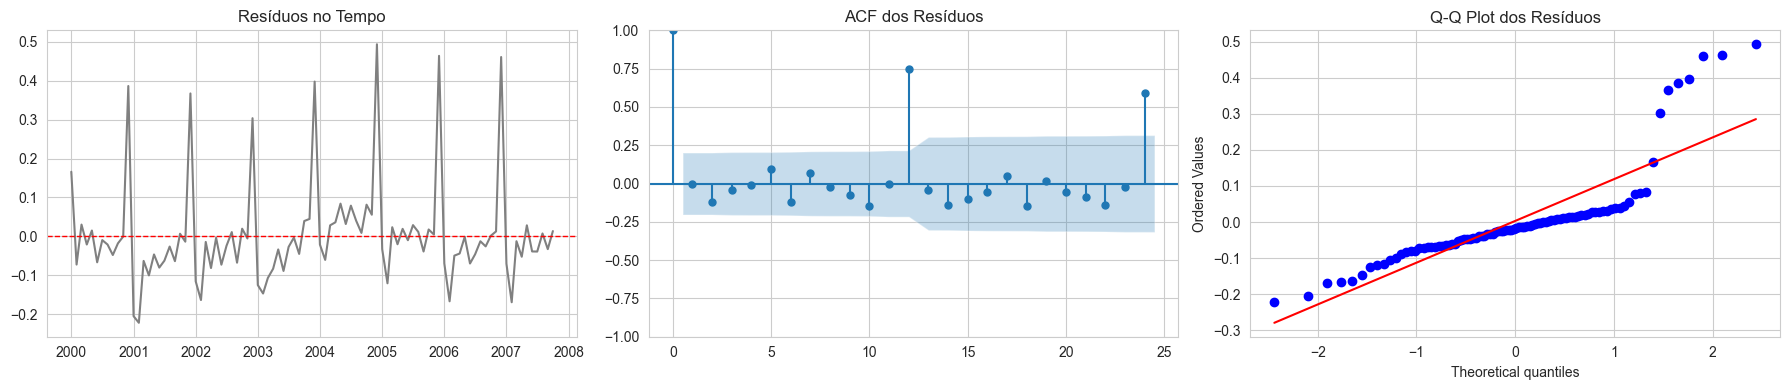

Ljung-Box (p > 0.05 → ruído branco):
     lb_stat  lb_pvalue
1   0.000938   0.975566
2   1.433190   0.488412
3   1.634297   0.651639
4   1.642248   0.801180
5   2.500964   0.776350
6   3.990982   0.677897
7   4.443022   0.727567
8   4.498819   0.809551
9   5.053902   0.829584
10  7.322616   0.694677


In [ ]:
residuos = arima_fit.resid.dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(residuos, color='gray')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Resíduos no Tempo')

plot_acf(residuos, lags=min(24, len(residuos)//3), ax=axes[1])
axes[1].set_title('ACF dos Resíduos')

stats.probplot(residuos, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot dos Resíduos')

plt.tight_layout(); plt.show()

# Teste Ljung-Box
lb = acorr_ljungbox(residuos, lags=10, return_df=True)
print("Ljung-Box (p > 0.05 → ruído branco):")
print(lb[['lb_stat', 'lb_pvalue']].to_string())

### 5.5 Previsão One-Step-Ahead

In [ ]:
# Fitted values no treino (offline)
arima_pred_train = arima_fit.fittedvalues.dropna()
train_aligned    = train_s.loc[arima_pred_train.index]

# Previsão online no teste (expanding window — um passo de cada vez)
print("Gerando previsões one-step-ahead no teste...")
history = list(train_s.values)
arima_pred_test = []
for t in range(len(test_s)):
    m    = ARIMA(history, order=best_order).fit()
    pred = float(np.array(m.forecast(steps=1)).flat[0])
    arima_pred_test.append(pred)
    history.append(float(test_s.iloc[t]))
arima_pred_test = np.array(arima_pred_test)
print(f"Concluído: {len(arima_pred_test)} previsões geradas.")

Gerando previsões one-step-ahead no teste...
Concluído: 48 previsões geradas.


### 5.6 Métricas e Gráficos

Métricas ARIMA
  Treino:  MSE=0.017417  MAPE=29.2172%
  Teste:  MSE=0.078303  MAPE=14.8104%


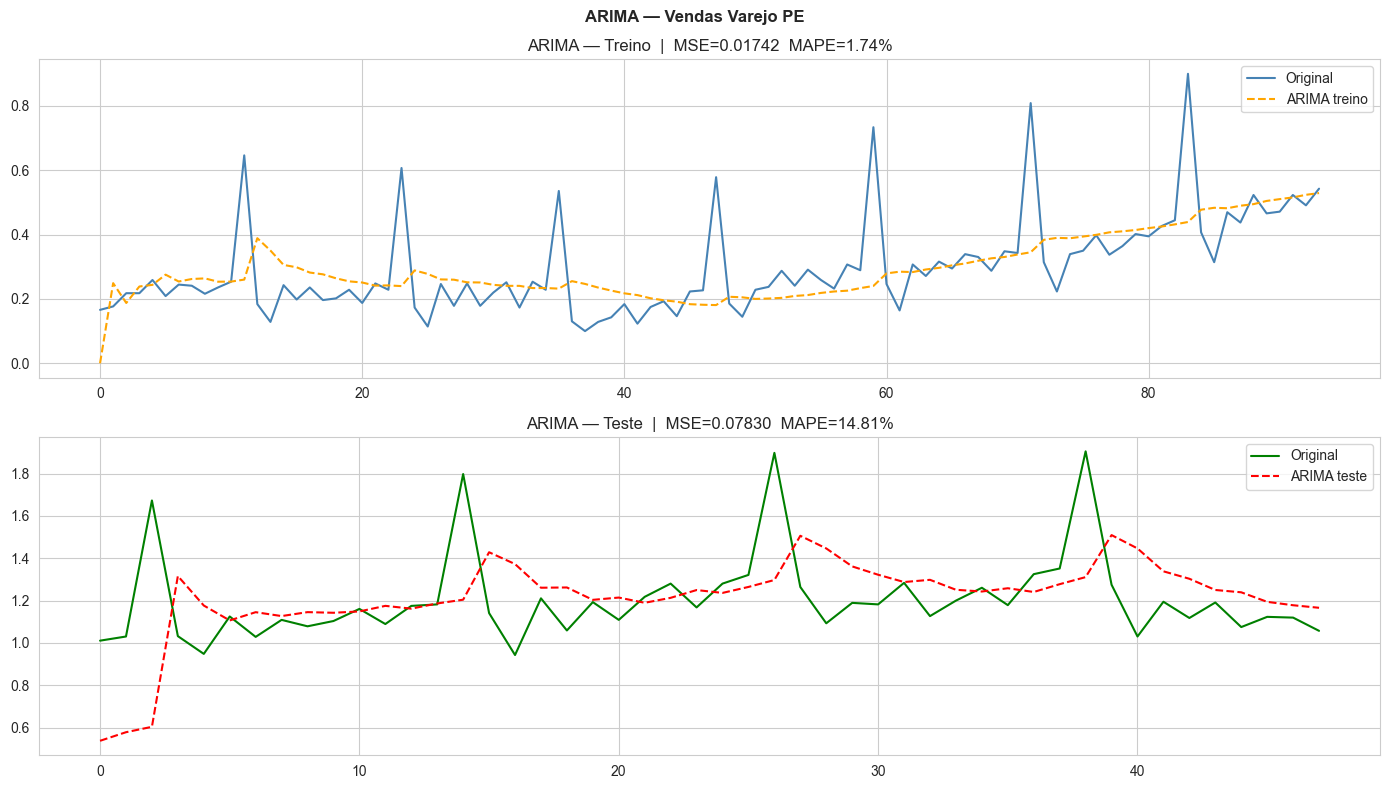

In [ ]:
print("="*50)
print("Métricas ARIMA")
print("="*50)
mse_ar_tr,  mape_ar_tr  = metricas(train_aligned, arima_pred_train, "Treino")
mse_ar_te,  mape_ar_te  = metricas(test_s,         arima_pred_test,  "Teste")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(train_aligned.values, label='Original',       color='steelblue')
axes[0].plot(arima_pred_train.values, label='ARIMA treino', color='orange', linestyle='--')
axes[0].set_title(f'ARIMA — Treino  |  MSE={mse_ar_tr:.5f}  MAPE={mse_ar_tr:.2%}')
axes[0].legend()

axes[1].plot(test_s.values, label='Original',      color='green')
axes[1].plot(arima_pred_test, label='ARIMA teste', color='red', linestyle='--')
axes[1].set_title(f'ARIMA — Teste  |  MSE={mse_ar_te:.5f}  MAPE={mape_ar_te:.2%}')
axes[1].legend()

plt.suptitle('ARIMA — Vendas Varejo PE', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. Modelo 2 — MLP (Multilayer Perceptron)

### 6.1 Janelamento Deslizante

In [ ]:
WINDOW = 12   # janela = período sazonal

all_data = np.concatenate([train_sc, val_sc, test_sc])
X_all, y_all = criar_janelas(all_data, WINDOW)

n_tr = len(train_sc) - WINDOW
n_va = len(val_sc)
n_te = len(test_sc)

X_tr, y_tr = X_all[:n_tr],          y_all[:n_tr]
X_va, y_va = X_all[n_tr:n_tr+n_va], y_all[n_tr:n_tr+n_va]
X_te, y_te = X_all[n_tr+n_va:],     y_all[n_tr+n_va:]

print(f"Janela: {WINDOW} | X_treino: {X_tr.shape} | X_val: {X_va.shape} | X_teste: {X_te.shape}")

Janela: 12 | X_treino: (82, 12) | X_val: (47, 12) | X_teste: (48, 12)


### 6.2 Random Search (seleção pelo conjunto de validação)

In [ ]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
}

best_mlp      = None
best_mse_val  = np.inf
resultados_mlp = []

for hidden in param_grid['hidden_layer_sizes']:
    for activation in param_grid['activation']:
        for lr in param_grid['learning_rate_init']:
            mses = []
            for seed in [42, 7, 13]:
                mlp = MLPRegressor(
                    hidden_layer_sizes=hidden, activation=activation,
                    learning_rate_init=lr, max_iter=500, random_state=seed
                )
                mlp.fit(X_tr, y_tr)
                mses.append(mean_squared_error(y_va, mlp.predict(X_va)))
            mse_mean = np.mean(mses)
            resultados_mlp.append({'hidden': str(hidden), 'activation': activation,
                                   'lr': lr, 'MSE_val': round(mse_mean, 6)})
            if mse_mean < best_mse_val:
                best_mse_val = mse_mean
                best_mlp = mlp   # último seed treinado, mas config vencedora

df_mlp = pd.DataFrame(resultados_mlp).sort_values('MSE_val').reset_index(drop=True)
print("Top 5 configurações MLP:")
print(df_mlp.head(5).to_string(index=False))
print(f"\nMelhor MLP: {best_mlp}")

Top 5 configurações MLP:
    hidden activation    lr  MSE_val
  (50, 50)       tanh 0.010 0.005447
     (50,)       tanh 0.010 0.006064
(100, 100)       tanh 0.001 0.006770
 (100, 50)       tanh 0.001 0.007337
 (100, 50)       relu 0.010 0.008012

Melhor MLP: MLPRegressor(activation='tanh', hidden_layer_sizes=(50, 50),
             learning_rate_init=0.01, max_iter=500, random_state=13)


### 6.3 Avaliação do Melhor Modelo MLP

Métricas MLP
  Treino:  MSE=0.002243  MAPE=15.8262%
  Validação:  MSE=0.004846  MAPE=6.1449%
  Teste:  MSE=0.033508  MAPE=11.6565%


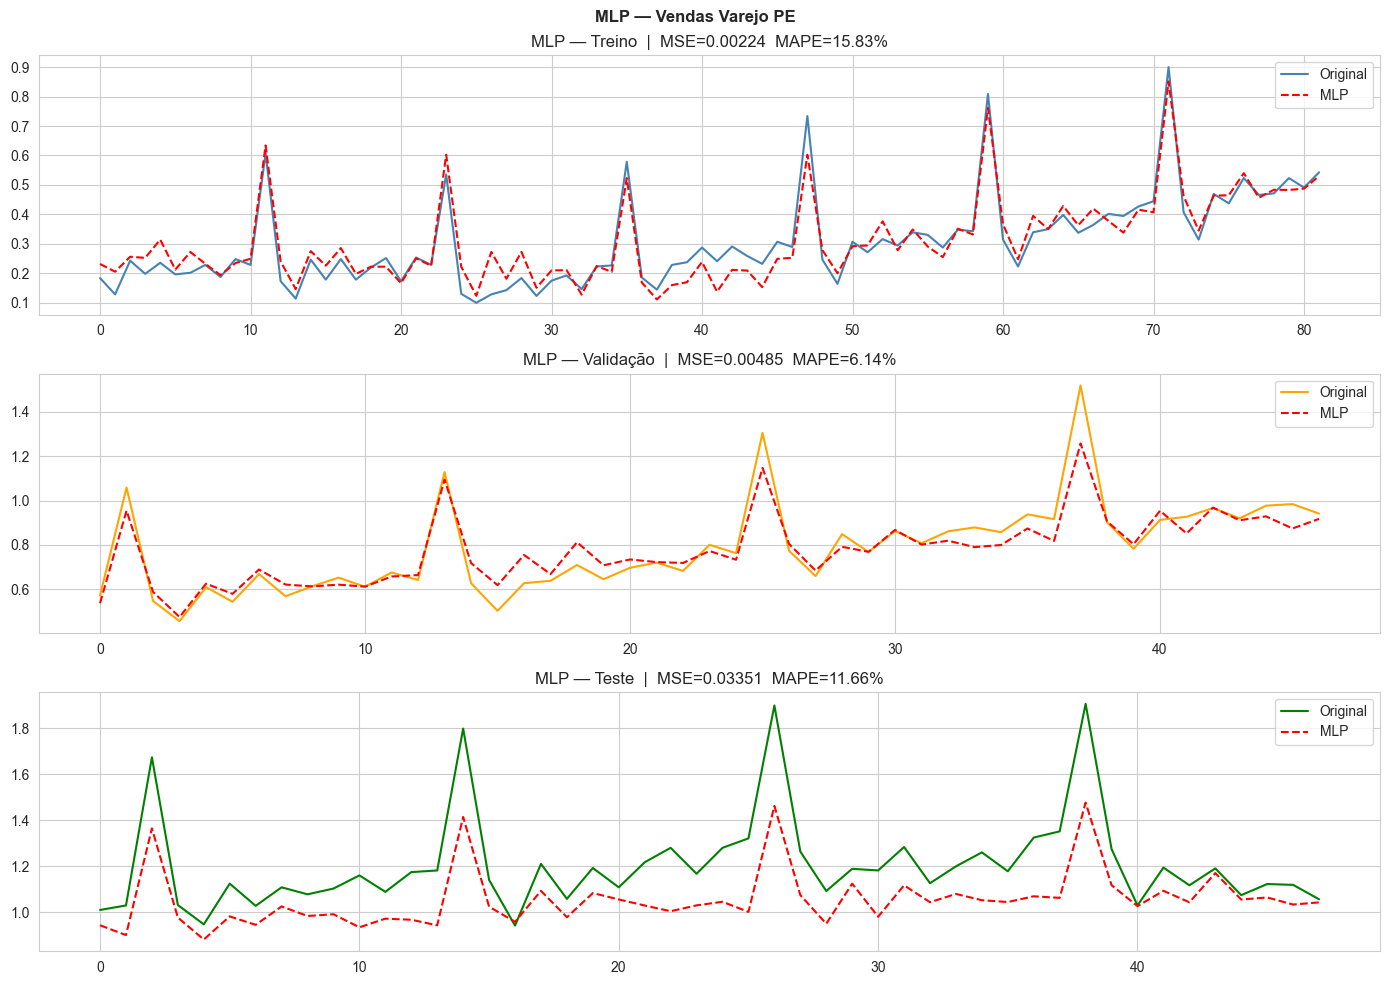

In [ ]:
mlp_pred_tr = best_mlp.predict(X_tr)
mlp_pred_va = best_mlp.predict(X_va)
mlp_pred_te = best_mlp.predict(X_te)

print("="*50)
print("Métricas MLP")
print("="*50)
mse_mlp_tr,  mape_mlp_tr  = metricas(y_tr, mlp_pred_tr, "Treino")
mse_mlp_va,  mape_mlp_va  = metricas(y_va, mlp_pred_va, "Validação")
mse_mlp_te,  mape_mlp_te  = metricas(y_te, mlp_pred_te, "Teste")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, y_t, y_p, lbl, mse, mape_v, col in [
    (axes[0], y_tr, mlp_pred_tr, 'Treino',    mse_mlp_tr, mape_mlp_tr, 'steelblue'),
    (axes[1], y_va, mlp_pred_va, 'Validação', mse_mlp_va, mape_mlp_va, 'orange'),
    (axes[2], y_te, mlp_pred_te, 'Teste',     mse_mlp_te, mape_mlp_te, 'green'),
]:
    ax.plot(y_t, label='Original', color=col)
    ax.plot(y_p, label='MLP',      color='red', linestyle='--')
    ax.set_title(f'MLP — {lbl}  |  MSE={mse:.5f}  MAPE={mape_v:.2%}')
    ax.legend()
plt.suptitle('MLP — Vendas Varejo PE', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 7. Modelo 3 — LSTM (Long Short-Term Memory)

### 7.1 Reshape dos Dados para LSTM [samples, timesteps, features]

In [ ]:
X_tr_l = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
X_va_l = X_va.reshape(X_va.shape[0], X_va.shape[1], 1)
X_te_l = X_te.reshape(X_te.shape[0], X_te.shape[1], 1)
print(f"X_treino LSTM: {X_tr_l.shape}")

X_treino LSTM: (82, 12, 1)


### 7.2 Busca de Hiperparâmetros LSTM

In [ ]:
configs_lstm = [
    {'units': 32,  'layers': 1, 'dropout': 0.1, 'batch': 16},
    {'units': 64,  'layers': 1, 'dropout': 0.2, 'batch': 16},
    {'units': 64,  'layers': 2, 'dropout': 0.2, 'batch': 32},
    {'units': 128, 'layers': 1, 'dropout': 0.2, 'batch': 16},
    {'units': 128, 'layers': 2, 'dropout': 0.3, 'batch': 32},
]

best_lstm      = None
best_mse_lstm  = np.inf
resultados_lstm = []

for cfg_l in configs_lstm:
    tf.random.set_seed(SEED)

    model = Sequential()
    return_seq = (cfg_l['layers'] > 1)
    model.add(LSTM(cfg_l['units'], return_sequences=return_seq, input_shape=(WINDOW, 1)))
    if cfg_l['layers'] > 1:
        model.add(LSTM(cfg_l['units'] // 2))
    model.add(Dropout(cfg_l['dropout']))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    model.fit(X_tr_l, y_tr,
              validation_data=(X_va_l, y_va),
              epochs=100, batch_size=cfg_l['batch'],
              callbacks=[es], verbose=0)

    val_pred = model.predict(X_va_l, verbose=0).flatten()
    mse_v    = mean_squared_error(y_va, val_pred)
    resultados_lstm.append({**cfg_l, 'MSE_val': round(mse_v, 6)})
    print(f"units={cfg_l['units']} layers={cfg_l['layers']} dropout={cfg_l['dropout']} | Val MSE={mse_v:.5f}")

    if mse_v < best_mse_lstm:
        best_mse_lstm = mse_v
        best_lstm = model

df_lstm = pd.DataFrame(resultados_lstm).sort_values('MSE_val').reset_index(drop=True)
print("\nResultados LSTM:")
print(df_lstm.to_string(index=False))
print(f"\nMelhor LSTM — Val MSE: {best_mse_lstm:.5f}")

units=32 layers=1 dropout=0.1 | Val MSE=0.04824
units=64 layers=1 dropout=0.2 | Val MSE=0.02819
units=64 layers=2 dropout=0.2 | Val MSE=0.02797
units=128 layers=1 dropout=0.2 | Val MSE=0.02919
units=128 layers=2 dropout=0.3 | Val MSE=0.02679

Resultados LSTM:
 units  layers  dropout  batch  MSE_val
   128       2      0.3     32 0.026788
    64       2      0.2     32 0.027974
    64       1      0.2     16 0.028185
   128       1      0.2     16 0.029185
    32       1      0.1     16 0.048243

Melhor LSTM — Val MSE: 0.02679


### 7.3 Avaliação do Melhor Modelo LSTM

Métricas LSTM
  Treino:  MSE=0.023929  MAPE=58.7956%
  Validação:  MSE=0.026788  MAPE=11.3069%
  Teste:  MSE=0.044572  MAPE=9.6946%


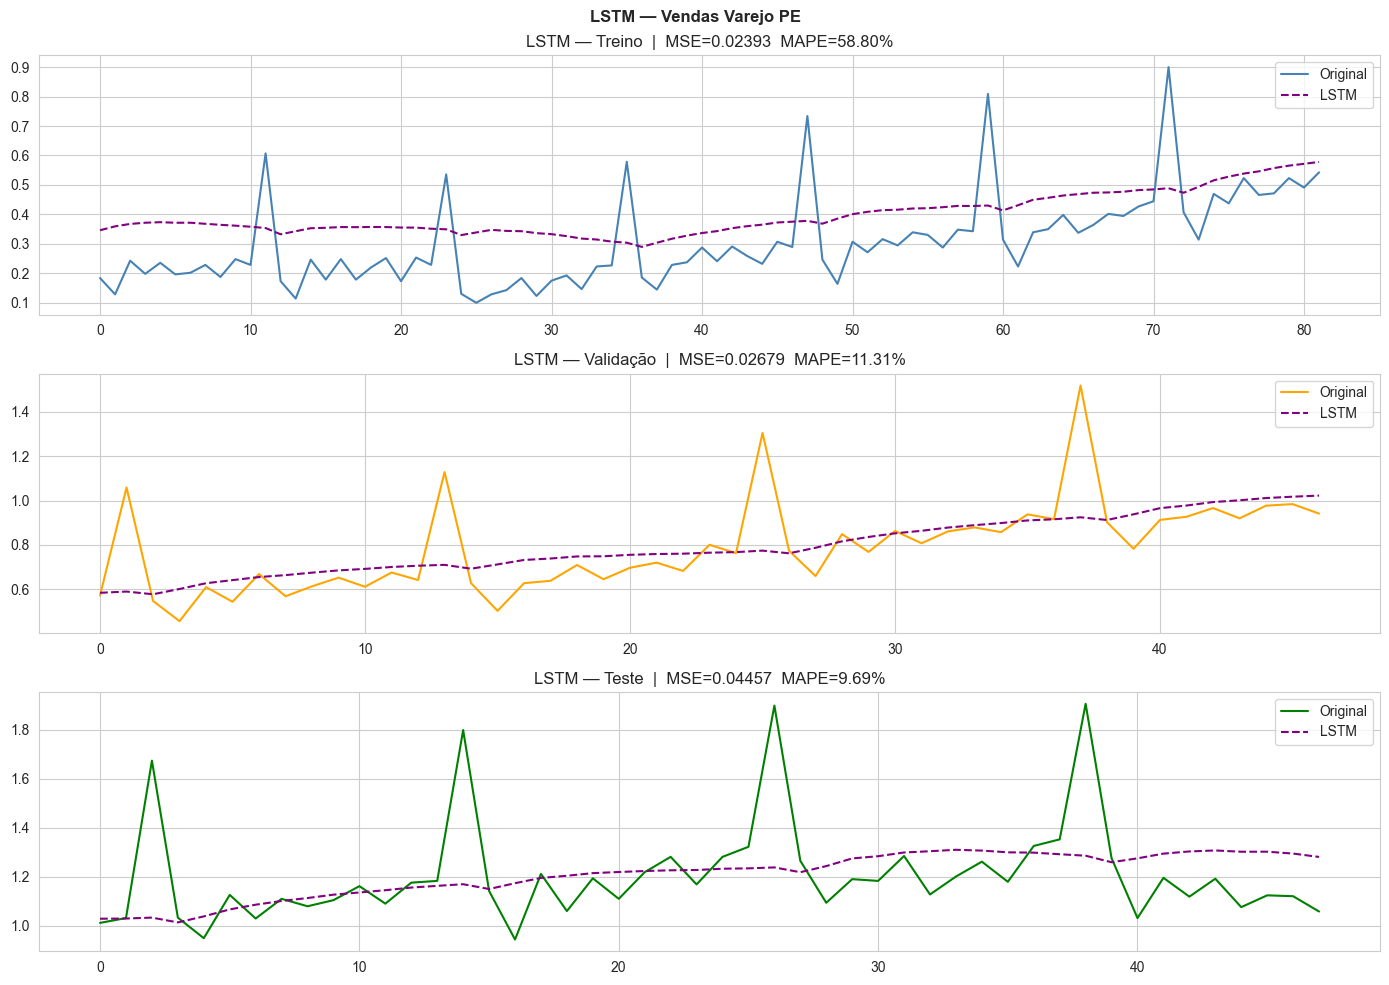

In [ ]:
lstm_pred_tr = best_lstm.predict(X_tr_l, verbose=0).flatten()
lstm_pred_va = best_lstm.predict(X_va_l, verbose=0).flatten()
lstm_pred_te = best_lstm.predict(X_te_l, verbose=0).flatten()

print("="*50)
print("Métricas LSTM")
print("="*50)
mse_lstm_tr,  mape_lstm_tr  = metricas(y_tr, lstm_pred_tr, "Treino")
mse_lstm_va,  mape_lstm_va  = metricas(y_va, lstm_pred_va, "Validação")
mse_lstm_te,  mape_lstm_te  = metricas(y_te, lstm_pred_te, "Teste")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, y_t, y_p, lbl, mse, mape_v, col in [
    (axes[0], y_tr, lstm_pred_tr, 'Treino',    mse_lstm_tr, mape_lstm_tr, 'steelblue'),
    (axes[1], y_va, lstm_pred_va, 'Validação', mse_lstm_va, mape_lstm_va, 'orange'),
    (axes[2], y_te, lstm_pred_te, 'Teste',     mse_lstm_te, mape_lstm_te, 'green'),
]:
    ax.plot(y_t, label='Original', color=col)
    ax.plot(y_p, label='LSTM',     color='purple', linestyle='--')
    ax.set_title(f'LSTM — {lbl}  |  MSE={mse:.5f}  MAPE={mape_v:.2%}')
    ax.legend()
plt.suptitle('LSTM — Vendas Varejo PE', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 8. Comparação dos Modelos

In [ ]:
comparacao = pd.DataFrame({
    'Modelo':      ['ARIMA', 'MLP', 'LSTM'],
    'MSE Treino':  [mse_ar_tr,  mse_mlp_tr,  mse_lstm_tr],
    'MAPE Treino': [mape_ar_tr, mape_mlp_tr, mape_lstm_tr],
    'MSE Val':     ['-',        mse_mlp_va,  mse_lstm_va],
    'MAPE Val':    ['-',        mape_mlp_va, mape_lstm_va],
    'MSE Teste':   [mse_ar_te,  mse_mlp_te,  mse_lstm_te],
    'MAPE Teste':  [mape_ar_te, mape_mlp_te, mape_lstm_te],
})

print("="*70)
print(f"COMPARAÇÃO DOS MODELOS — Vendas Varejo PE")
print("="*70)
print(comparacao.to_string(index=False))
print("="*70)

# Identificar melhor por MSE no teste
mse_test_vals = [mse_ar_te, mse_mlp_te, mse_lstm_te]
melhor_idx    = np.argmin(mse_test_vals)
print(f"\nMelhor modelo (menor MSE no Teste): {['ARIMA', 'MLP', 'LSTM'][melhor_idx]}")

COMPARAÇÃO DOS MODELOS — Vendas Varejo PE
Modelo  MSE Treino  MAPE Treino   MSE Val  MAPE Val  MSE Teste  MAPE Teste
 ARIMA    0.017417     0.292172         -         -   0.078303    0.148104
   MLP    0.002243     0.158262  0.004846  0.061449   0.033508    0.116565
  LSTM    0.023929     0.587956  0.026788  0.113069   0.044572    0.096946

Melhor modelo (menor MSE no Teste): MLP


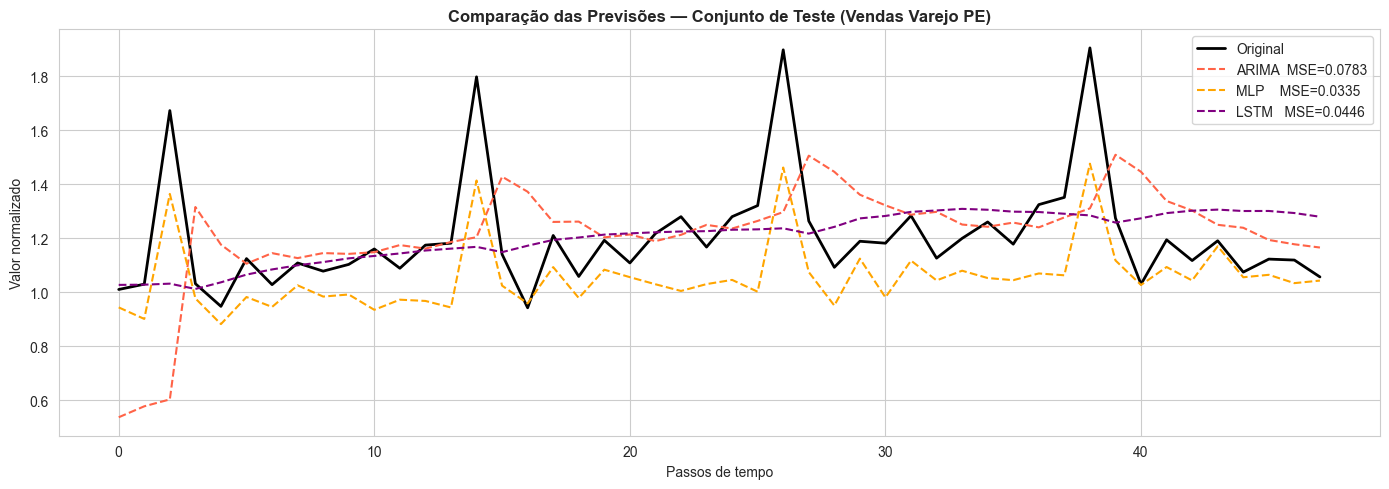

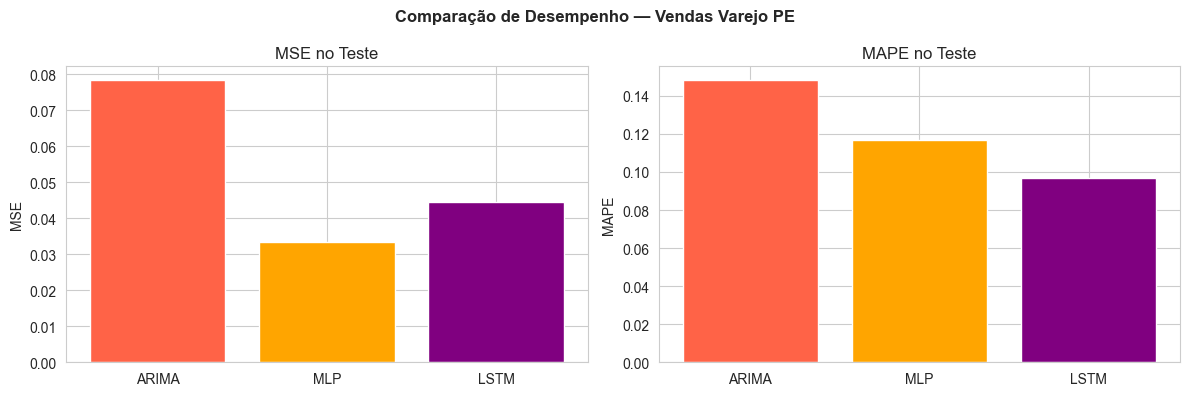

In [ ]:
# Gráfico comparativo no conjunto de TESTE
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_te,           label='Original',                     color='black',  linewidth=2)
ax.plot(arima_pred_test, label=f'ARIMA  MSE={mse_ar_te:.4f}',  linestyle='--', color='tomato')
ax.plot(mlp_pred_te,     label=f'MLP    MSE={mse_mlp_te:.4f}', linestyle='--', color='orange')
ax.plot(lstm_pred_te,    label=f'LSTM   MSE={mse_lstm_te:.4f}',linestyle='--', color='purple')
ax.set_title('Comparação das Previsões — Conjunto de Teste (Vendas Varejo PE)', fontweight='bold')
ax.set_xlabel('Passos de tempo'); ax.set_ylabel('Valor normalizado')
ax.legend(); plt.tight_layout(); plt.show()

# Barplot de MSE no teste
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
modelos = ['ARIMA', 'MLP', 'LSTM']
cores   = ['tomato', 'orange', 'purple']

axes[0].bar(modelos, [mse_ar_te,  mse_mlp_te,  mse_lstm_te],  color=cores)
axes[0].set_title('MSE no Teste'); axes[0].set_ylabel('MSE')

axes[1].bar(modelos, [mape_ar_te, mape_mlp_te, mape_lstm_te], color=cores)
axes[1].set_title('MAPE no Teste'); axes[1].set_ylabel('MAPE')

plt.suptitle('Comparação de Desempenho — Vendas Varejo PE', fontweight='bold')
plt.tight_layout(); plt.show()